# Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


# Data Understanding


In [2]:
df = pd.read_csv(r'DataProduksi.csv')
df

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,Jan-09,1427.10,50.00,8.80
1,Feb-09,1188.00,45.50,7.90
2,Mar-09,1346.70,40.10,8.50
3,Apr-09,1193.50,38.80,9.30
4,May-09,1239.50,47.20,10.30
...,...,...,...,...
115,Aug-18,2075.95,35.32,5.99
116,Sep-18,2093.69,49.37,6.78
117,Oct-18,2075.70,51.21,8.12
118,Nov-18,1931.94,48.77,8.48


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tanggal       120 non-null    object 
 1   Minyak Sawit  120 non-null    float64
 2   Karet Kering  120 non-null    float64
 3   Teh           120 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.9+ KB


# Preprocessing


## Change date format


In [4]:
df['Tanggal'] = pd.to_datetime(
    df['Tanggal'], format='%b-%y').dt.strftime('%Y-%m')
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,1427.1,50.0,8.8
1,2009-02,1188.0,45.5,7.9
2,2009-03,1346.7,40.1,8.5
3,2009-04,1193.5,38.8,9.3
4,2009-05,1239.5,47.2,10.3


## Separating DataFrame Columns into Separate Variables


In [5]:
dates = df['Tanggal'].values
minyak_sawit = df['Minyak Sawit'].values
karet_kering = df['Karet Kering'].values
teh = df['Teh'].values

## Windowed Dataset


In [6]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1:]))
    return ds.batch(batch_size).prefetch(1)

## Split Dataset


In [7]:
def split_data(X, y, split_percentage):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split_percentage, shuffle=False)
    return X_train, X_test, y_train, y_test

## Normalization


In [8]:
scaler = MinMaxScaler()
def normalization(data):
    return scaler.fit_transform(data.reshape(-1, 1))


def to_original_value(data):
    return scaler.inverse_transform(data.reshape(-1, 1))

# Generate Output


## Generate R2 Score


In [9]:
def generate_r2(y_test, y_pred):
    r2 = r2_score(y_test,y_pred)
    print("R2 score: {:.2%}".format(r2))

## Generate Plot

In [10]:
def generate_plot(X_data, y_data, X_name, y_name, attribute_name):
    plt.figure(figsize=(10, 6))
    plt.plot(X_data, label=X_name)
    plt.plot(y_data, label=y_name)
    plt.title(f'{X_name} vs {y_name} {attribute_name}')
    plt.xlabel('Bulan')
    plt.ylabel('Nilai Produksi')
    plt.legend()
    plt.show()
    print('\n')

# LSTM model


In [11]:
def model_lstm(data, attribute_name, split_percentage=0.8, epochs=50):
    X_train, X_test, y_train, y_test = split_data(normalization(data), normalization(data), split_percentage)

    model = Sequential([
        LSTM(60, return_sequences=True),
        Dropout(0.2),
        LSTM(60, return_sequences=True),
        Dropout(0.2),
        LSTM(60, return_sequences=True),
        Dropout(0.2),
        LSTM(60),
        Dropout(0.2),
        Dense(30, activation="relu"),
        Dense(10, activation="relu"),
        Dense(1)
    ])
    model.compile(loss="mae", optimizer=tf.keras.optimizers.Adam() , metrics=["mae"])
    model.fit(tf.expand_dims(X_train, axis=-1), tf.expand_dims(y_train, axis=-1), epochs=epochs, verbose=1)


    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)

    generate_r2(y_test, y_pred)

    generate_plot(to_original_value(y_test), to_original_value(y_pred), 'Data Test', 'Data Prediksi', attribute_name)
    generate_plot(to_original_value(X_train), to_original_value(train_pred), 'Data Training','Data Prediksi', attribute_name)


# LSTM Evaluation


## Minyak Sawit


Epoch 1/50
2/2 [==============================] - 6s 9ms/step - loss: 0.2558 - mae: 0.2558
Epoch 2/50
2/2 [==============================] - 0s 8ms/step - loss: 0.2467 - mae: 0.2467
Epoch 3/50
2/2 [==============================] - 0s 8ms/step - loss: 0.2363 - mae: 0.2363
Epoch 4/50
2/2 [==============================] - 0s 8ms/step - loss: 0.2250 - mae: 0.2250
Epoch 5/50
2/2 [==============================] - 0s 8ms/step - loss: 0.2120 - mae: 0.2120
Epoch 6/50
2/2 [==============================] - 0s 9ms/step - loss: 0.1992 - mae: 0.1992
Epoch 7/50
2/2 [==============================] - 0s 9ms/step - loss: 0.1854 - mae: 0.1854
Epoch 8/50
2/2 [==============================] - 0s 3ms/step - loss: 0.1724 - mae: 0.1724
Epoch 9/50
2/2 [==============================] - 0s 7ms/step - loss: 0.1591 - mae: 0.1591
Epoch 10/50
2/2 [==============================] - 0s 0s/step - loss: 0.1425 - mae: 0.1425
Epoch 11/50
2/2 [==============================] - 0s 8ms/step - loss: 0.1310 - mae: 0.131

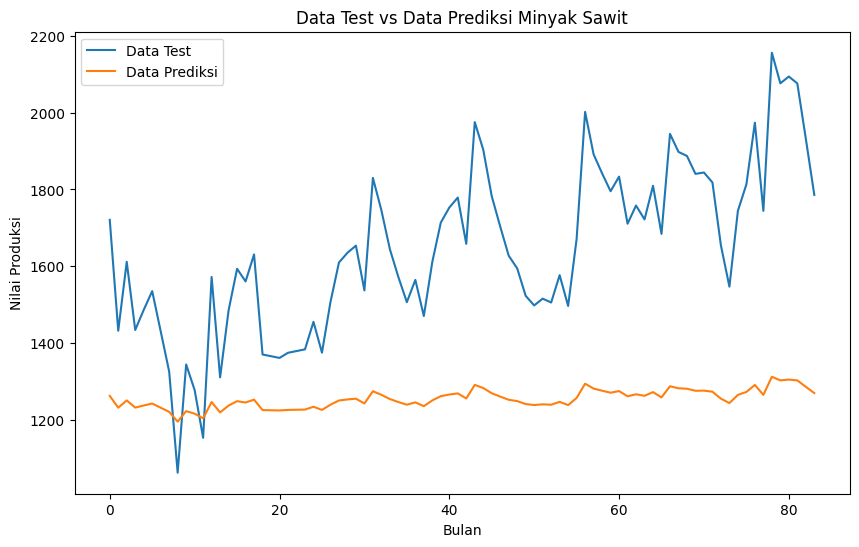

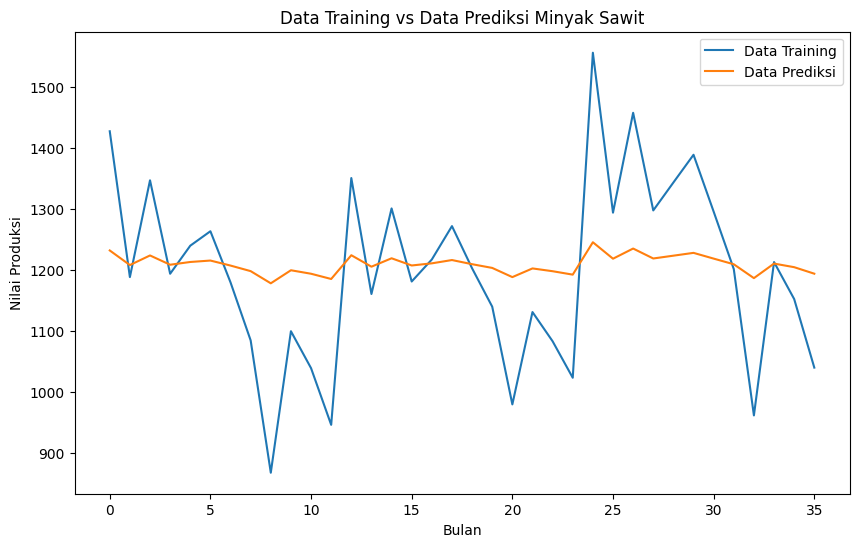

In [12]:
model_lstm(minyak_sawit, 'Minyak Sawit', 0.7, 50)

## Karet Kering


Epoch 1/50
1/1 [==============================] - 5s 5s/step - loss: 0.2464 - mae: 0.2464
Epoch 2/50
1/1 [==============================] - 0s 16ms/step - loss: 0.2390 - mae: 0.2390
Epoch 3/50
1/1 [==============================] - 0s 12ms/step - loss: 0.2310 - mae: 0.2310
Epoch 4/50
1/1 [==============================] - 0s 4ms/step - loss: 0.2224 - mae: 0.2224
Epoch 5/50
1/1 [==============================] - 0s 7ms/step - loss: 0.2139 - mae: 0.2139
Epoch 6/50
1/1 [==============================] - 0s 9ms/step - loss: 0.2042 - mae: 0.2042
Epoch 7/50
1/1 [==============================] - 0s 9ms/step - loss: 0.1948 - mae: 0.1948
Epoch 8/50
1/1 [==============================] - 0s 15ms/step - loss: 0.1854 - mae: 0.1854
Epoch 9/50
1/1 [==============================] - 0s 10ms/step - loss: 0.1745 - mae: 0.1745
Epoch 10/50
1/1 [==============================] - 0s 7ms/step - loss: 0.1634 - mae: 0.1634
Epoch 11/50
1/1 [==============================] - 0s 8ms/step - loss: 0.1518 - mae: 0

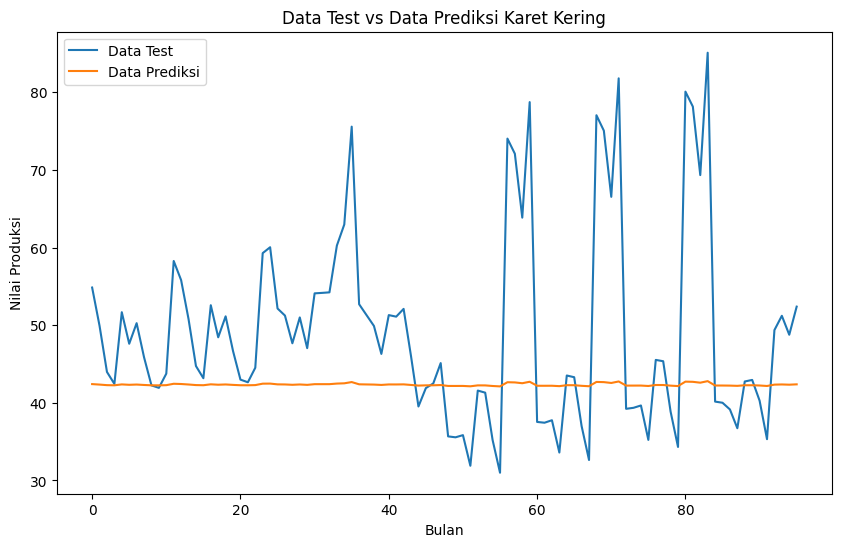

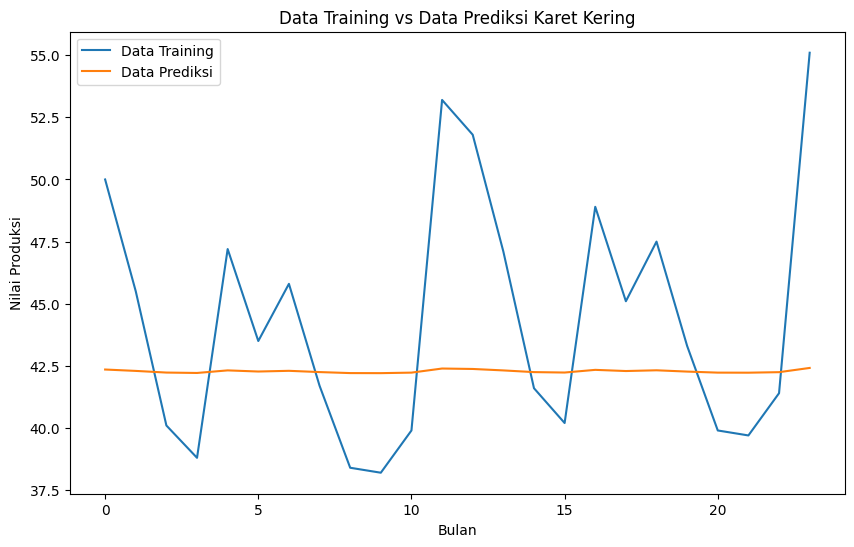

In [13]:
model_lstm(karet_kering, 'Karet Kering', 0.8, 50)


## Teh


Epoch 1/50
1/1 [==============================] - 7s 7s/step - loss: 0.6197 - mae: 0.6197
Epoch 2/50
1/1 [==============================] - 0s 9ms/step - loss: 0.6163 - mae: 0.6163
Epoch 3/50
1/1 [==============================] - 0s 8ms/step - loss: 0.6121 - mae: 0.6121
Epoch 4/50
1/1 [==============================] - 0s 9ms/step - loss: 0.6075 - mae: 0.6075
Epoch 5/50
1/1 [==============================] - 0s 10ms/step - loss: 0.6029 - mae: 0.6029
Epoch 6/50
1/1 [==============================] - 0s 10ms/step - loss: 0.5982 - mae: 0.5982
Epoch 7/50
1/1 [==============================] - 0s 6ms/step - loss: 0.5933 - mae: 0.5933
Epoch 8/50
1/1 [==============================] - 0s 10ms/step - loss: 0.5884 - mae: 0.5884
Epoch 9/50
1/1 [==============================] - 0s 8ms/step - loss: 0.5831 - mae: 0.5831
Epoch 10/50
1/1 [==============================] - 0s 8ms/step - loss: 0.5776 - mae: 0.5776
Epoch 11/50
1/1 [==============================] - 0s 8ms/step - loss: 0.5723 - mae: 0.

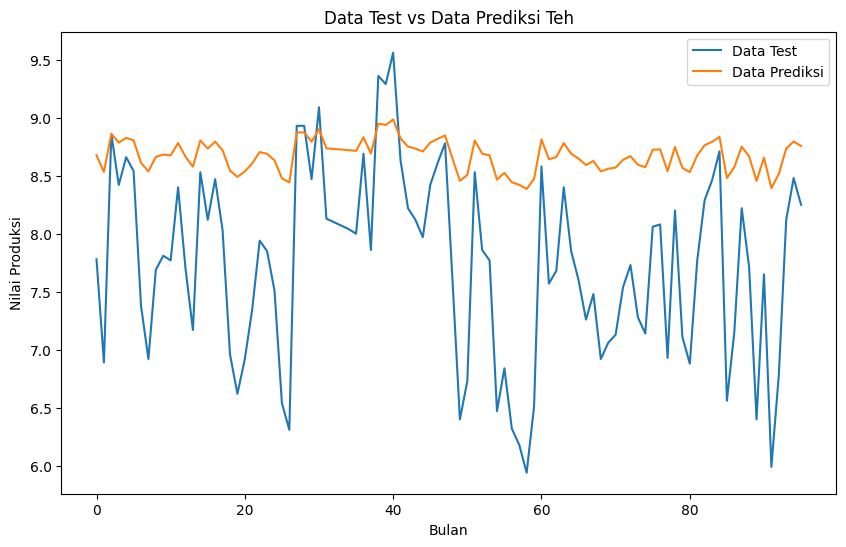

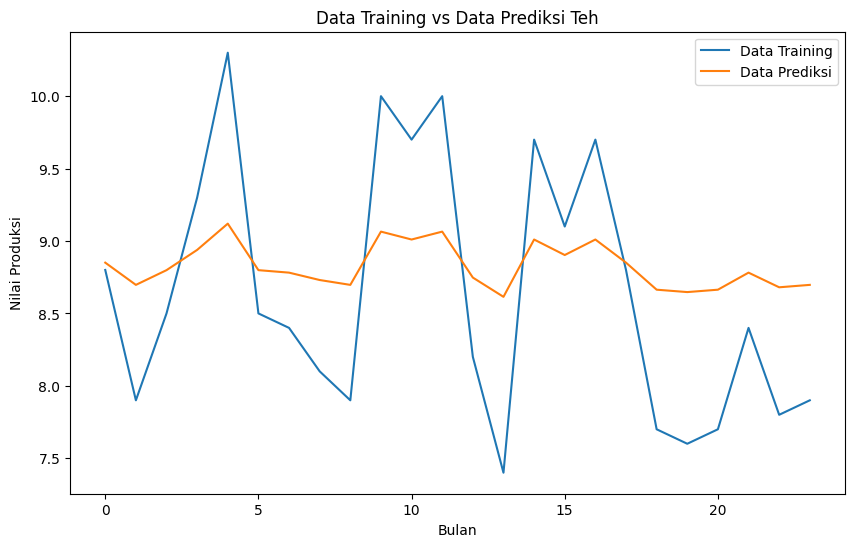

In [14]:
model_lstm(teh, 'Teh', 0.8, 50)


# SVR Model


In [15]:
def model_svr(data, attribute_name, split_percentage=0.8, c=1000, gamma='scale', epsilon=0.1):
    X_train, X_test, y_train, y_test = split_data(normalization(data), normalization(data), split_percentage)


    model = SVR(kernel='rbf', C=c, gamma=gamma, epsilon=epsilon)
    model.fit(X_train.reshape(-1,1), y_train.ravel())
    

    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train.reshape(-1,1))

    generate_r2(y_test, y_pred)

    generate_plot(to_original_value(y_test), to_original_value(y_pred), 'Data Test', 'Data Prediksi', attribute_name)
    generate_plot(to_original_value(X_train), to_original_value(train_pred), 'Data Training','Data Prediksi', attribute_name)

# SVR Evaluation


## Minyak Sawit


R2 score: 99.25%


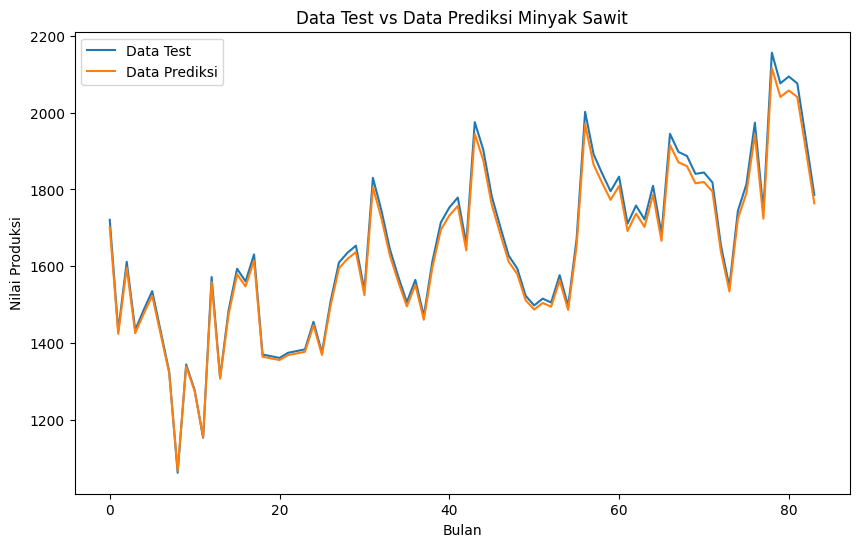

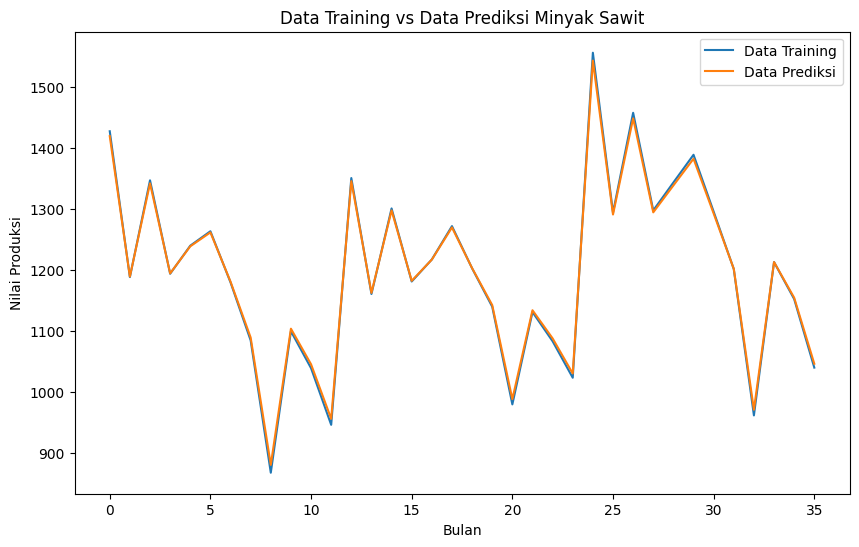

In [16]:
model_svr(minyak_sawit, 'Minyak Sawit', 0.7, 100, .01, .01)

## Karet Kering


R2 score: 99.47%


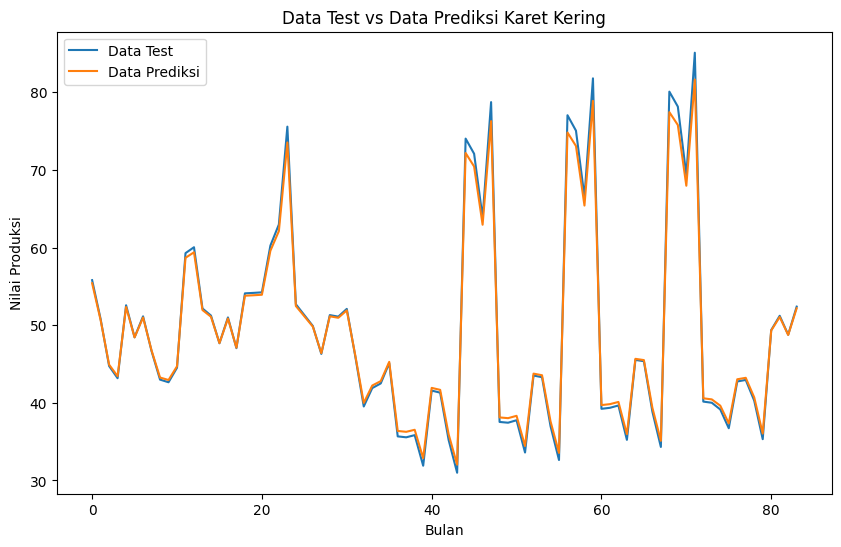

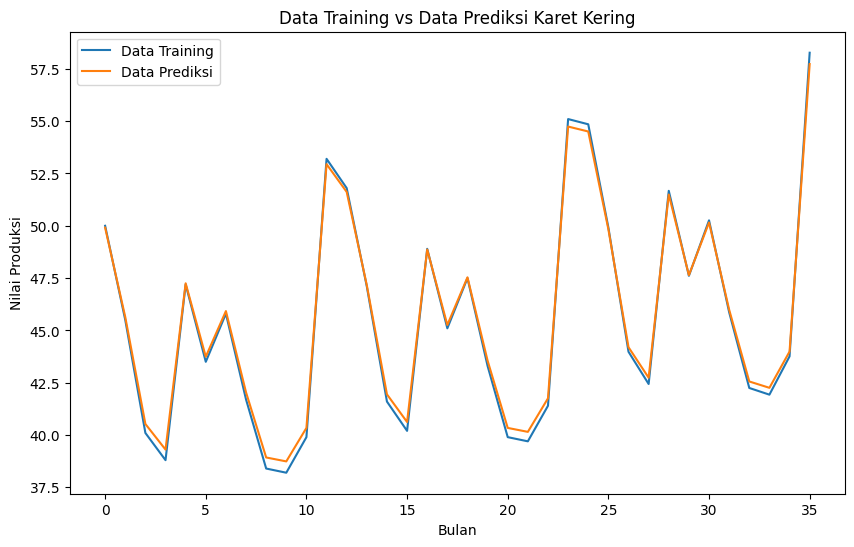

In [17]:
model_svr(karet_kering, 'Karet Kering', 0.7, 100, .1, .01)

## Teh


R2 score: 99.49%


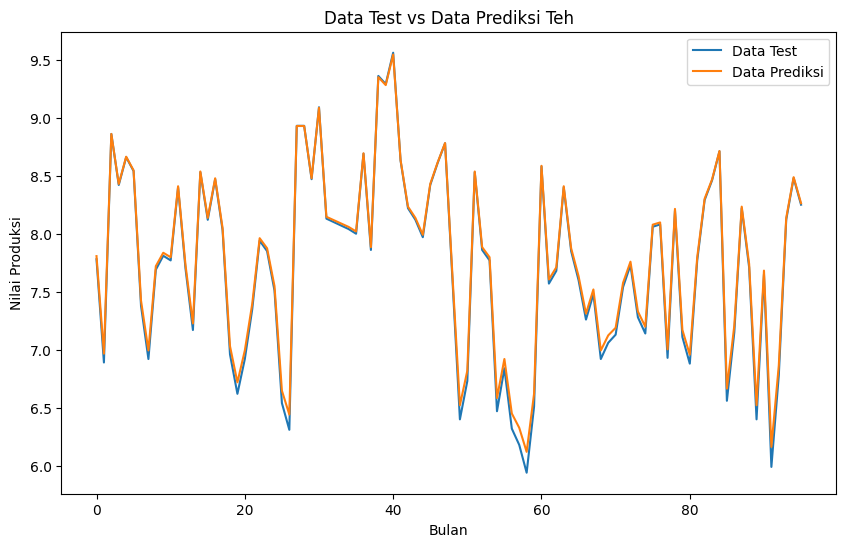

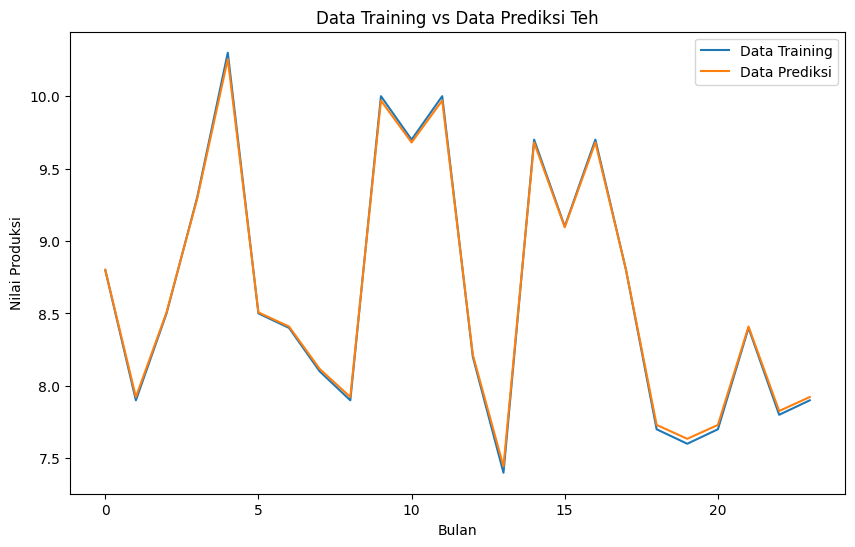

In [18]:
model_svr(teh, 'Teh', 0.8, 100, .1, .01)